# Parameter Analysis Figures (Lab Experiments)

This notebook generates four figures requested for the paper using lab experiments only.

In [25]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent  # one level above this notebook's folder
LIT_PATH = BASE_DIR / 'batch_processing/output_xlsx/agentic_extraction_7papers_rawmd.xlsx'
INT_PATH = BASE_DIR / 'science-data_and_code/data/processed_data/df_analysis_learn.csv'

plt.rcParams.update({'figure.dpi': 120})


In [26]:
lit = pd.read_excel(LIT_PATH, sheet_name='extractions')
intg = pd.read_csv(INT_PATH)

lab = lit[lit['METHOD_lab'] == True].copy()

MISSING_MARKERS = {'N/R', 'N/A', 'NA', 'NR'}

CONFIG_COLS = [
    'CONFIG_playerCount', 'CONFIG_numRounds', 'CONFIG_allOrNothing',
    'CONFIG_defaultContribProp', 'CONFIG_MPCR', 'CONFIG_chat',
    'CONFIG_showOtherSummaries', 'CONFIG_showPunishmentId',
    'CONFIG_showRewardId', 'CONFIG_showNRounds',
    'CONFIG_punishmentExists', 'CONFIG_punishmentCost',
    'CONFIG_punishmentTech', 'CONFIG_rewardExists',
    'CONFIG_rewardCost', 'CONFIG_rewardTech', 'CONFIG_endowment'
]

CONFIG_COLS_NO_ENDOW = [c for c in CONFIG_COLS if c != 'CONFIG_endowment']
CONFIG_COLS_FOR_MISSING = CONFIG_COLS_NO_ENDOW  # include rewardCost/rewardTech, exclude endowment

LABELS = {
    'CONFIG_playerCount': 'Group size (players)',
    'CONFIG_numRounds': 'Number of rounds',
    'CONFIG_allOrNothing': 'All-or-nothing',
    'CONFIG_defaultContribProp': 'Opt-out contribution mechanism',
    'CONFIG_MPCR': 'MPCR',
    'CONFIG_chat': 'Chat enabled',
    'CONFIG_showOtherSummaries': 'Show other summaries',
    'CONFIG_showPunishmentId': 'Show punishment ID',
    'CONFIG_showRewardId': 'Show reward ID',
    'CONFIG_showNRounds': 'Show number of rounds',
    'CONFIG_punishmentExists': 'Punishment exists',
    'CONFIG_punishmentCost': 'Punishment cost',
    'CONFIG_punishmentTech': 'Punishment tech',
    'CONFIG_rewardExists': 'Reward exists',
    'CONFIG_rewardCost': 'Reward cost',
    'CONFIG_rewardTech': 'Reward tech',
}

def _missing_mask(s, include_neg1=False):
    if s.dtype == object:
        s_str = s.astype(str).str.strip()
        miss = s.isna() | s_str.eq('') | s_str.str.upper().isin(MISSING_MARKERS)
        if include_neg1:
            s_num = pd.to_numeric(s_str, errors='coerce')
            miss = miss | (s_num == -1)
        return miss
    miss = s.isna()
    if include_neg1:
        miss = miss | (s == -1)
    return miss

def cleaned_series(df, col):
    s = df[col]
    if s.dtype == object:
        s = s.dropna()
        s = s[~s.astype(str).str.strip().str.upper().isin(MISSING_MARKERS)]
    else:
        s = s.dropna()
    if s.dtype == bool:
        s = s.astype(int)
    s_num = pd.to_numeric(s, errors='coerce')
    if len(s) > 0 and s_num.notna().mean() >= 0.8:
        return s_num.dropna()
    return s

def is_binary(s):
    vals = pd.Series(s).dropna().unique().tolist()
    return set(vals).issubset({0, 1, True, False})

def evenness_metric(s):
    s = pd.Series(s).dropna()
    if len(s) == 0:
        return 0.0
    p = s.value_counts(normalize=True)
    if len(p) <= 1:
        return 0.0
    entropy = -(p * np.log2(p)).sum()
    return float(entropy / np.log2(len(p)))

def entropy_metric_from_bins(s, bins):
    s = pd.to_numeric(pd.Series(s), errors='coerce').dropna()
    if len(s) == 0:
        return 0.0
    counts, _ = np.histogram(s, bins=bins)
    if counts.sum() == 0:
        return 0.0
    p = counts[counts > 0] / counts.sum()
    if len(p) <= 1:
        return 0.0
    entropy = -(p * np.log2(p)).sum()
    return float(entropy / np.log2(len(p)))


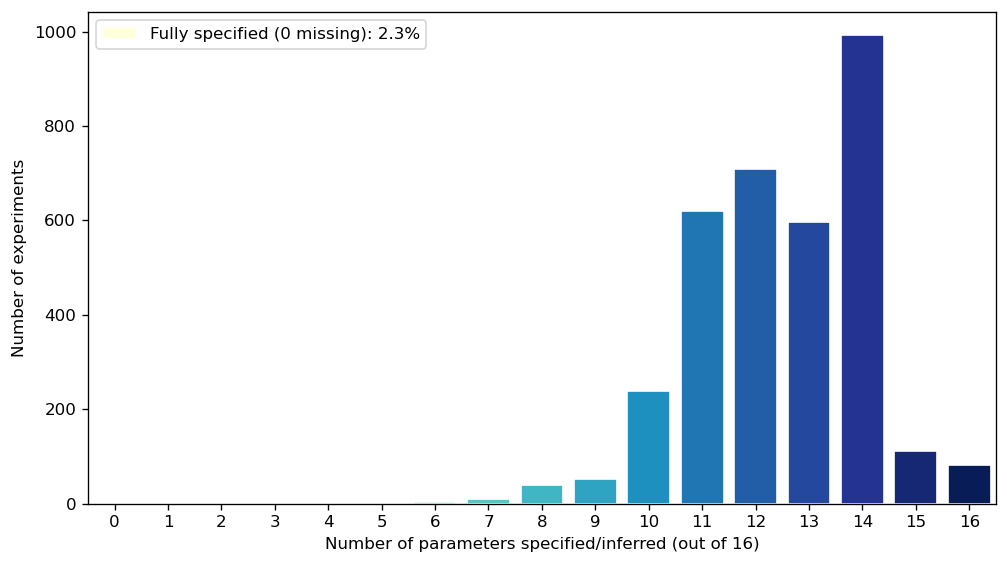

In [27]:
# 1) Specified/inferred CONFIG parameters per lab experiment
missing_counts = pd.Series(0, index=lab.index)
for col in CONFIG_COLS_FOR_MISSING:
    missing_counts += _missing_mask(lab[col], include_neg1=True).astype(int)

total_params = len(CONFIG_COLS_FOR_MISSING)
specified_counts = total_params - missing_counts

counts = specified_counts.value_counts().sort_index()
counts = counts.reindex(range(0, total_params + 1), fill_value=0)

x = counts.index.values
y = counts.values

cmap = plt.cm.YlGnBu
colors = [cmap(i / max(1, total_params)) for i in x]

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.bar(x, y, color=colors, edgecolor='white')

ax.set_xlabel(f'Number of parameters specified/inferred (out of {total_params})')
ax.set_ylabel('Number of experiments')

fully_spec = (missing_counts == 0).mean() * 100
more_than_half = (missing_counts > (total_params / 2)).mean() * 100

legend_text = [
    f'Fully specified (0 missing): {fully_spec:.1f}%',
    f'More than half missing: {more_than_half:.1f}%',
]
ax.legend(legend_text, loc='upper left', frameon=True)

ax.set_xticks(x)
ax.set_xlim(-0.5, total_params + 0.5)
plt.tight_layout()
plt.show()


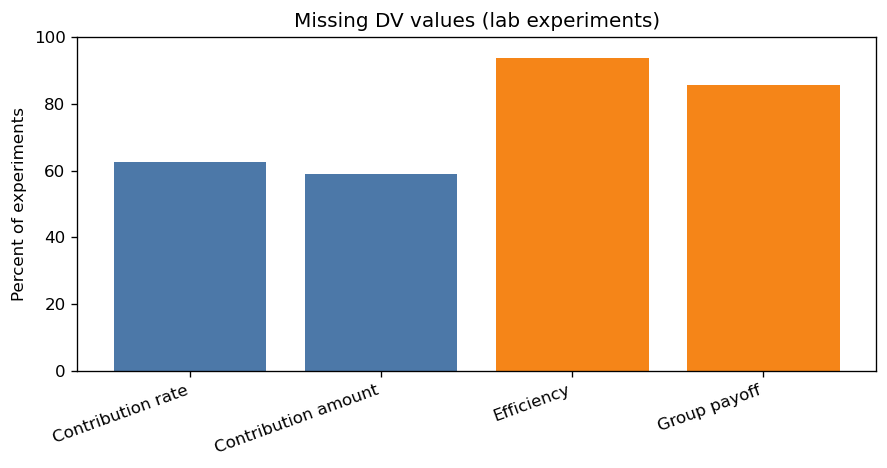

In [28]:
# 2) Missing DV values (percent of experiments)
dv_cols = ['DV_contributionRate', 'DV_contributionAmount', 'DV_efficiency', 'DV_groupPayoff']
dv_labels = ['Contribution rate', 'Contribution amount', 'Efficiency', 'Group payoff']
missing_pct = []
total = len(lab)
for col in dv_cols:
    missing_pct.append(_missing_mask(lab[col]).sum() / total * 100)

colors = ['#4c78a8', '#4c78a8', '#f58518', '#f58518']
fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.bar(dv_labels, missing_pct, color=colors)
ax.set_ylabel('Percent of experiments')
ax.set_ylim(0, 100)
ax.set_title('Missing DV values (lab experiments)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


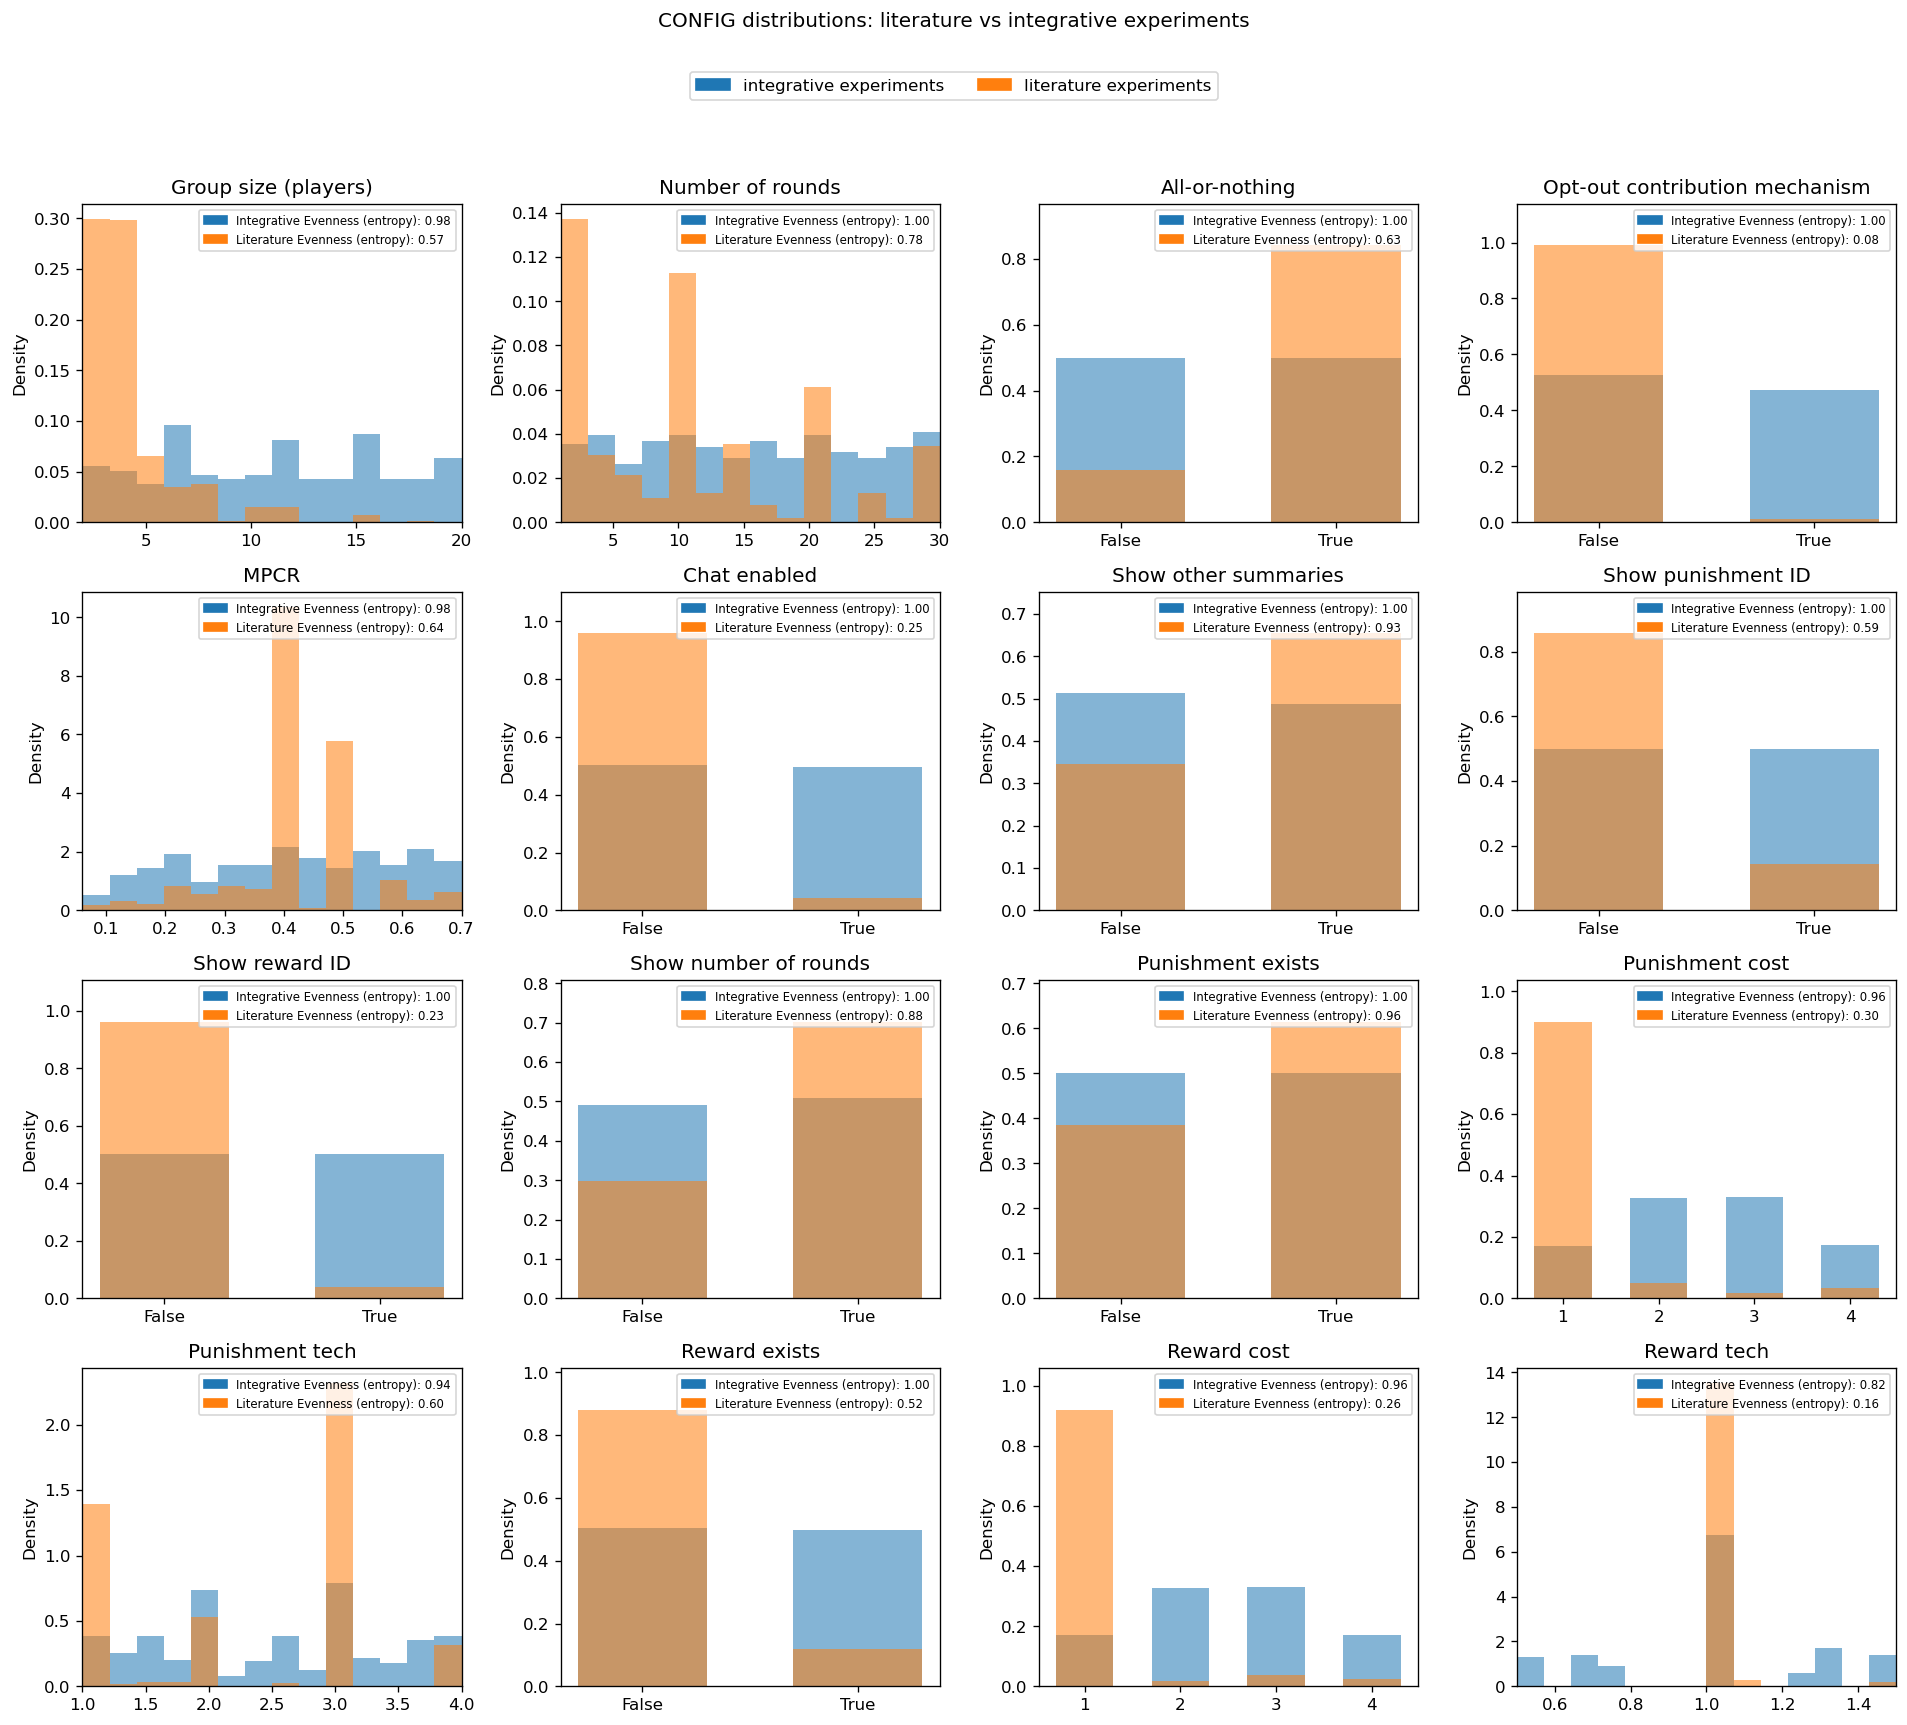

In [29]:
# 3) CONFIG distributions: literature vs integrative experiments (density)
plot_cols = [
    'CONFIG_playerCount', 'CONFIG_numRounds', 'CONFIG_allOrNothing',
    'CONFIG_defaultContribProp', 'CONFIG_MPCR', 'CONFIG_chat',
    'CONFIG_showOtherSummaries', 'CONFIG_showPunishmentId',
    'CONFIG_showRewardId', 'CONFIG_showNRounds',
    'CONFIG_punishmentExists', 'CONFIG_punishmentCost',
    'CONFIG_punishmentTech', 'CONFIG_rewardExists',
    'CONFIG_rewardCost', 'CONFIG_rewardTech'
]

n_cols = 4
n_rows = int(np.ceil(len(plot_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.6 * n_rows))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    ax = axes[i]
    s_int_raw = cleaned_series(intg, col)
    s_lit_raw = cleaned_series(lab, col)

    if len(s_int_raw) == 0:
        ax.set_visible(False)
        continue

    is_bin = is_binary(s_int_raw)
    nunique_int = pd.Series(s_int_raw).dropna().nunique()
    use_evenness = is_bin or nunique_int <= 5

    if is_bin:
        s_int = pd.to_numeric(s_int_raw, errors='coerce').dropna().astype(int)
        s_lit = pd.to_numeric(s_lit_raw, errors='coerce').dropna().astype(int)
        categories = [0, 1]
        s_int = s_int[s_int.isin(categories)]
        s_lit = s_lit[s_lit.isin(categories)]

        int_counts = s_int.value_counts(normalize=True).reindex(categories, fill_value=0)
        lit_counts = s_lit.value_counts(normalize=True).reindex(categories, fill_value=0)

        x = np.array(categories)
        ax.bar(x, int_counts.values, width=0.6, alpha=0.55, color='#1f77b4', label='integrative experiments')
        ax.bar(x, lit_counts.values, width=0.6, alpha=0.55, color='#ff7f0e', label='literature experiments')
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['False', 'True'])
        ax.set_ylim(0, max(int_counts.max(), lit_counts.max()) * 1.15 + 1e-9)

        metric_name = 'Evenness (entropy)'
        m_int = evenness_metric(s_int)
        m_lit = evenness_metric(s_lit)

    elif use_evenness:
        s_int = pd.to_numeric(s_int_raw, errors='coerce').dropna()
        s_lit = pd.to_numeric(s_lit_raw, errors='coerce').dropna()
        categories = sorted(s_int.unique())
        s_lit = s_lit[s_lit.isin(categories)]

        int_counts = s_int.value_counts(normalize=True).reindex(categories, fill_value=0)
        lit_counts = s_lit.value_counts(normalize=True).reindex(categories, fill_value=0)

        ax.bar(categories, int_counts.values, width=0.6, alpha=0.55, color='#1f77b4', label='integrative experiments')
        ax.bar(categories, lit_counts.values, width=0.6, alpha=0.55, color='#ff7f0e', label='literature experiments')
        ax.set_xticks(categories)
        ax.set_ylim(0, max(int_counts.max(), lit_counts.max()) * 1.15 + 1e-9)

        metric_name = 'Evenness (entropy)'
        m_int = evenness_metric(s_int)
        m_lit = evenness_metric(s_lit)

    else:
        s_int = pd.to_numeric(s_int_raw, errors='coerce').dropna()
        s_lit = pd.to_numeric(s_lit_raw, errors='coerce').dropna()

        if len(s_int) == 0:
            ax.set_visible(False)
            continue

        min_i, max_i = s_int.min(), s_int.max()
        s_lit = s_lit[(s_lit >= min_i) & (s_lit <= max_i)]

        if min_i == max_i:
            ax.axvline(min_i, color='#1f77b4', linewidth=2, label='integrative experiments')
            if len(s_lit) > 0:
                ax.axvline(s_lit.median(), color='#ff7f0e', linewidth=2, label='literature experiments')
            bins = np.linspace(min_i - 0.5, max_i + 0.5, 2)
        else:
            bins = np.linspace(min_i, max_i, 15)
            ax.hist(s_int, bins=bins, density=True, alpha=0.55, color='#1f77b4', label='integrative experiments')
            ax.hist(s_lit, bins=bins, density=True, alpha=0.55, color='#ff7f0e', label='literature experiments')
            ax.set_xlim(min_i, max_i)

        metric_name = 'Evenness (entropy)'
        m_int = entropy_metric_from_bins(s_int, bins)
        m_lit = entropy_metric_from_bins(s_lit, bins)

    ax.set_title(LABELS.get(col, col))
    ax.set_ylabel('Density')

    # per-subplot legend with spread/evenness
    from matplotlib.patches import Patch
    handles = [
        Patch(color='#1f77b4', label=f'Integrative {metric_name}: {m_int:.2f}'),
        Patch(color='#ff7f0e', label=f'Literature {metric_name}: {m_lit:.2f}'),
    ]
    ax.legend(handles=handles, loc='upper right', fontsize=7, frameon=True)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Single legend for the whole figure (moved slightly down)
from matplotlib.patches import Patch
global_handles = [
    Patch(color='#1f77b4', label='integrative experiments'),
    Patch(color='#ff7f0e', label='literature experiments'),
]
fig.legend(global_handles, ['integrative experiments', 'literature experiments'], loc='upper center', bbox_to_anchor=(0.5, 0.965), ncol=2, frameon=True)
fig.suptitle('CONFIG distributions: literature vs integrative experiments', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


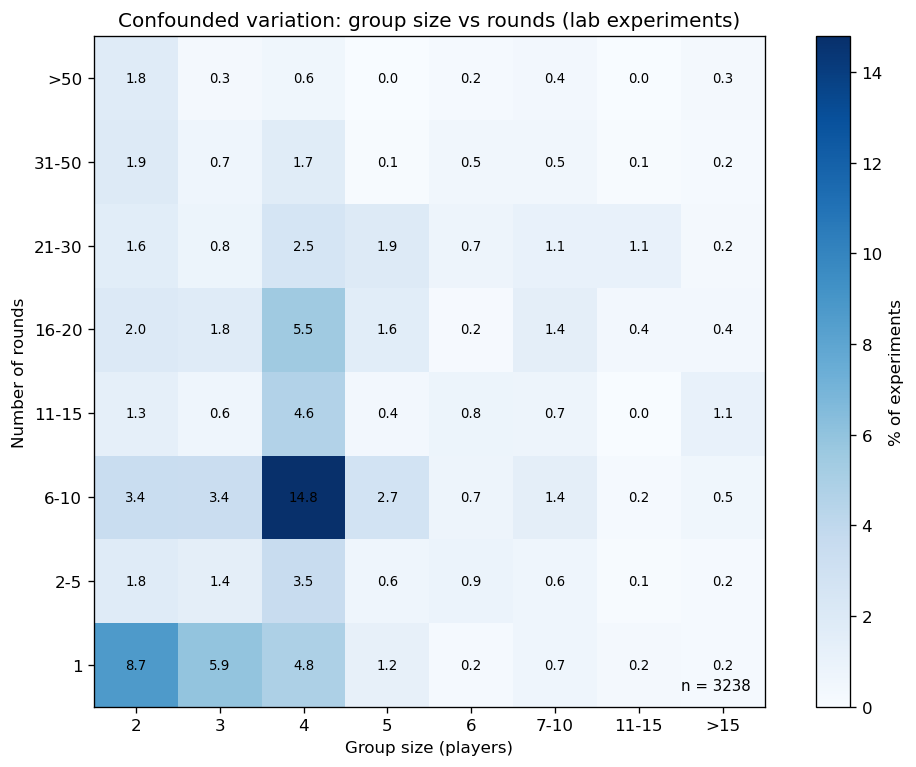

In [30]:
# 4) Confounded variation heatmap: playerCount vs numRounds
pc = cleaned_series(lab, 'CONFIG_playerCount')
nr = cleaned_series(lab, 'CONFIG_numRounds')

pc_num = pd.to_numeric(pc, errors='coerce').dropna()
nr_num = pd.to_numeric(nr, errors='coerce').dropna()

df_heat = pd.DataFrame({
    'playerCount': pc_num,
    'numRounds': nr_num,
}).dropna()

# Keep only non-negative values
df_heat = df_heat[(df_heat['playerCount'] >= 2) & (df_heat['numRounds'] >= 1)]

group_bins = [2, 3, 4, 5, 6, 7, 11, 16, np.inf]
group_labels = ['2', '3', '4', '5', '6', '7-10', '11-15', '>15']

round_bins = [1, 2, 6, 11, 16, 21, 31, 51, np.inf]
round_labels = ['1', '2-5', '6-10', '11-15', '16-20', '21-30', '31-50', '>50']

df_heat['group_bin'] = pd.cut(df_heat['playerCount'], bins=group_bins, labels=group_labels, right=False)
df_heat['round_bin'] = pd.cut(df_heat['numRounds'], bins=round_bins, labels=round_labels, right=False)

df_heat = df_heat.dropna(subset=['group_bin', 'round_bin'])

counts = pd.crosstab(df_heat['round_bin'], df_heat['group_bin']).reindex(index=round_labels, columns=group_labels, fill_value=0)
percent = counts / counts.values.sum() * 100

fig, ax = plt.subplots(figsize=(9, 6.5))
im = ax.imshow(percent.values, cmap='Blues', origin='lower')

ax.set_xticks(range(len(group_labels)))
ax.set_xticklabels(group_labels)
ax.set_yticks(range(len(round_labels)))
ax.set_yticklabels(round_labels)

ax.set_xlabel('Group size (players)')
ax.set_ylabel('Number of rounds')

# annotate cells
for i in range(percent.shape[0]):
    for j in range(percent.shape[1]):
        val = percent.values[i, j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8, color='black')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('% of experiments')

ax.set_title('Confounded variation: group size vs rounds (lab experiments)')
ax.text(0.98, 0.02, f'n = {counts.values.sum()}', transform=ax.transAxes, ha='right', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
